In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
import joblib

In [2]:
# Load the dataset
df = pd.read_csv('dataset.csv')

In [3]:
# Display the first few rows of the dataset
df.head()

,Temperature,Humidity,Moisture,MQ135,AC_Voltage,AC_Current,Dust,Room_Condition
0,24.247241,59.014286,51.959818,27.959755,214.680559,1.623978,64.520903,Excellent
1,27.197057,52.022300,51.242177,10.617535,239.097296,4.329771,103.084778,Excellent
2,23.090950,43.668090,39.127267,25.742693,222.958351,2.164917,202.963224,Excellent
3,22.836963,45.842893,40.990855,23.682100,233.555279,1.798695,178.558610,Excellent
4,25.554487,40.929008,48.226346,15.115724,211.951548,4.795542,291.408008,Excellent


In [4]:
df.shape

(20000, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     20000 non-null  float64
 1   Humidity        20000 non-null  float64
 2   Moisture        20000 non-null  float64
 3   MQ135           20000 non-null  float64
 4   AC_Voltage      20000 non-null  float64
 5   AC_Current      20000 non-null  float64
 6   Dust            20000 non-null  float64
 7   Room_Condition  20000 non-null  object 
dtypes: float64(7), object(1)
memory usage: 1.2+ MB


In [6]:
# Check for missing values
print(df.isnull().sum())

Temperature       0
Humidity          0
Moisture          0
MQ135             0
AC_Voltage        0
AC_Current        0
Dust              0
Room_Condition    0
dtype: int64


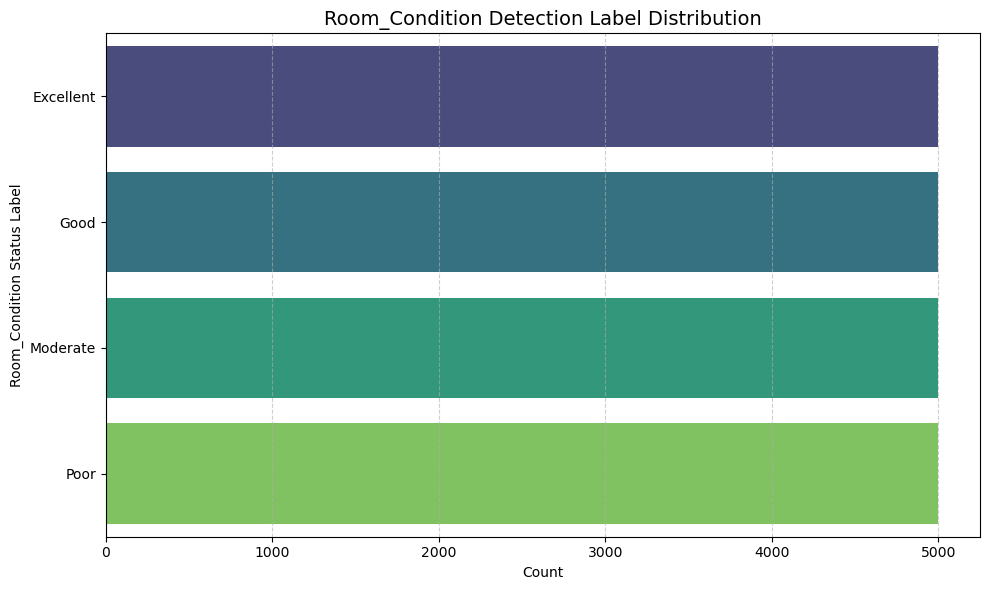

In [7]:
# Plot distribution safely for Seaborn ≥ 0.14
plt.figure(figsize=(10, 6))
sns.countplot(
    y='Room_Condition',
    data=df,
    order=df['Room_Condition'].value_counts().index,
    hue='Room_Condition',               # use label as hue to satisfy new seaborn requirement
    dodge=False,               # prevents double bars
    legend=False,              # hides redundant legend
    palette='viridis'
)
plt.title('Room_Condition Detection Label Distribution', fontsize=14)
plt.xlabel('Count')
plt.ylabel('Room_Condition Status Label')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Correlation Matrix:
             Temperature  Humidity  Moisture     MQ135  AC_Voltage  \
Temperature     1.000000 -0.017486 -0.007602 -0.030515   -0.005777   
Humidity       -0.017486  1.000000  0.005893  0.112749    0.011005   
Moisture       -0.007602  0.005893  1.000000  0.104370   -0.008436   
MQ135          -0.030515  0.112749  0.104370  1.000000   -0.035785   
AC_Voltage     -0.005777  0.011005 -0.008436 -0.035785    1.000000   
AC_Current     -0.032105  0.096108  0.107293  0.774949   -0.052400   
Dust           -0.030574  0.108882  0.110732  0.904498   -0.023475   

             AC_Current      Dust  
Temperature   -0.032105 -0.030574  
Humidity       0.096108  0.108882  
Moisture       0.107293  0.110732  
MQ135          0.774949  0.904498  
AC_Voltage    -0.052400 -0.023475  
AC_Current     1.000000  0.771460  
Dust           0.771460  1.000000  


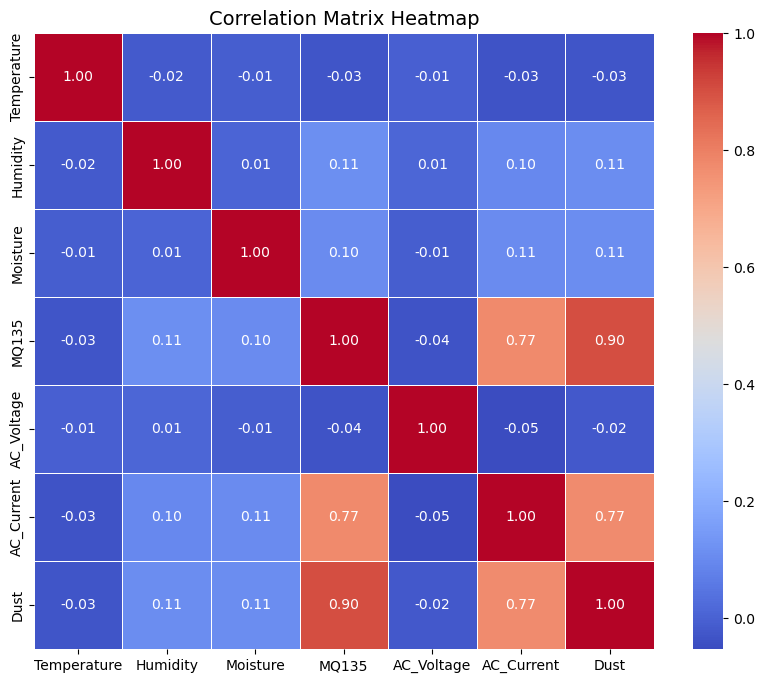

In [8]:
# Filter out non-numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])

# Calculate and display the correlation matrix
print("\nCorrelation Matrix:")
correlation_matrix = numeric_df.corr()
print(correlation_matrix)

# Plotting the heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap', fontsize=14)
plt.show()


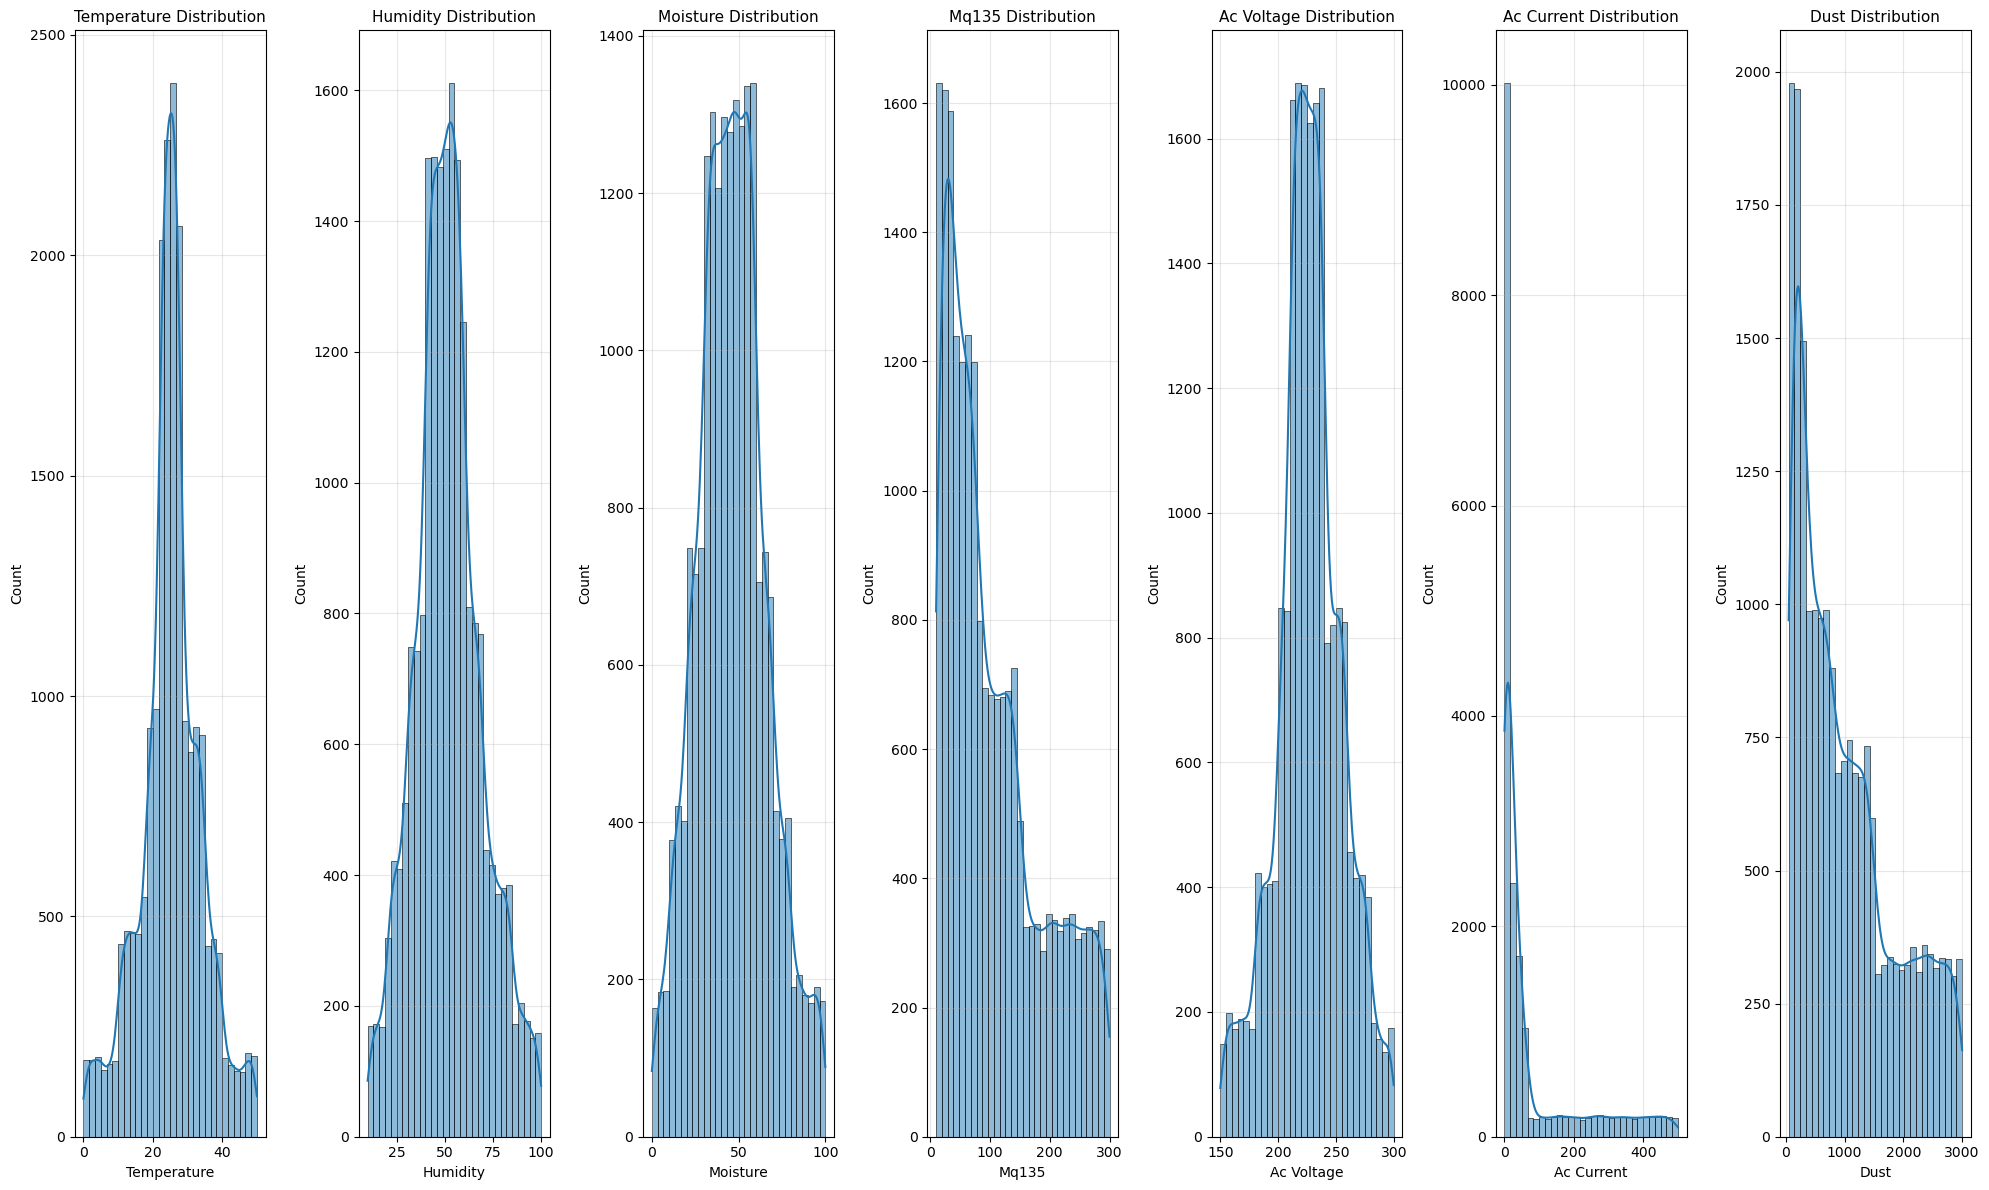

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# List of feature columns (MUST be strings)
columns = ["Temperature","Humidity","Moisture","MQ135","AC_Voltage","AC_Current","Dust"]
						
# Plot settings
plt.figure(figsize=(20, 12))

# Create subplots (3 rows × 4 columns = 12 plots)
for i, column in enumerate(columns, start=1):
    plt.subplot(1, 7, i)
    sns.histplot(df[column], bins=30, kde=True)
    plt.title(f"{column.replace('_', ' ').title()} Distribution", fontsize=11)
    plt.xlabel(column.replace('_', ' ').title())
    plt.ylabel("Count")
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [10]:
# Encode the target variable
label_encoder = LabelEncoder()
df['Room_Condition'] = label_encoder.fit_transform(df['Room_Condition'])


In [11]:
import joblib
joblib.dump(label_encoder, 'label_encoder.pkl')

['label_encoder.pkl']

In [12]:
# Split the data into features and target
X = df.drop(columns=['Room_Condition'])
y = df['Room_Condition']


In [13]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [14]:
# Scale the features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create and train the Random Forest model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate the model
rf_accuracy = accuracy_score(y_test, y_pred_rf) * 100  # Convert to percentage
print(f"Random Forest Accuracy: {rf_accuracy:.2f}%")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       995
           1       1.00      1.00      1.00      1024
           2       1.00      1.00      1.00      1004
           3       1.00      1.00      1.00       977

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



In [25]:
# Save the trained models and scaler
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [26]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create and train the Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1)
gb_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_gb = gb_model.predict(X_test_scaled)

# Evaluate the model
gb_accuracy = accuracy_score(y_test, y_pred_gb) * 100  # Convert to percentage
print(f"Gradient Boosting Accuracy: {gb_accuracy:.2f}%")
print(classification_report(y_test, y_pred_gb))
joblib.dump(gb_model, 'gb_model.pkl')


Gradient Boosting Accuracy: 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       995
           1       1.00      1.00      1.00      1024
           2       1.00      1.00      1.00      1004
           3       1.00      1.00      1.00       977

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



['gb_model.pkl']

In [31]:
import requests
import pandas as pd
import joblib

# ==========================
# LOAD TRAINED ML FILES
# ==========================
rf_model = joblib.load("rf_model.pkl")
scaler = joblib.load("scaler.pkl")
label_encoder = joblib.load("label_encoder.pkl")

# ==========================
# BLYNK CONFIGURATION
# ==========================
BLYNK_TOKEN = "uyyj0idr0hKbeadefrT6vZnBuCZCxg_7"
						
URLS = {
    "Temperature": f"https://blynk.cloud/external/api/get?token={BLYNK_TOKEN}&V0",
    "Humidity": f"https://blynk.cloud/external/api/get?token={BLYNK_TOKEN}&V1",
    "Moisture": f"https://blynk.cloud/external/api/get?token={BLYNK_TOKEN}&V2",
    "MQ135": f"https://blynk.cloud/external/api/get?token={BLYNK_TOKEN}&V3",
    "AC_Voltage": f"https://blynk.cloud/external/api/get?token={BLYNK_TOKEN}&V4",
    "AC_Current": f"https://blynk.cloud/external/api/get?token={BLYNK_TOKEN}&V5",
    "Dust": f"https://blynk.cloud/external/api/get?token={BLYNK_TOKEN}&V6",
}

UPDATE_RESULT_V9 = f"https://blynk.cloud/external/api/update?token={BLYNK_TOKEN}&V9="

# ==========================
# FETCH SENSOR VALUE
# ==========================
def fetch(url):
    return float(requests.get(url, timeout=5).text)

# ==========================
# ML PREDICTION FUNCTION
# ==========================
def room_condition():   						

    data = {
        "Temperature": fetch(URLS["Temperature"]),
        "Humidity": fetch(URLS["Humidity"]),
        "Moisture": fetch(URLS["Moisture"]),
        "MQ135": fetch(URLS["MQ135"]),
        "AC_Voltage": fetch(URLS["AC_Voltage"]),
        "AC_Current": fetch(URLS["AC_Current"]),
        "Dust": fetch(URLS["Dust"]),
    }

    df = pd.DataFrame([data])

    scaled = scaler.transform(df)
    pred = rf_model.predict(scaled)
    result = label_encoder.inverse_transform(pred)[0]

    return result, data

# ==========================
# MAIN EXECUTION
# ==========================
if __name__ == "__main__":
    try:
        result, sensor_data = room_condition()

        print("\n📊 Sensor Values:")
        for k, v in sensor_data.items():
            print(f"{k:15}: {v}")

        print("\n🧠 RF Model Prediction:", result)

        # Send to Blynk
        requests.get(UPDATE_RESULT_V9)

        print("📤 Prediction alert sent to Blynk")

    except Exception as e:
        print("❌ Error:", e)



📊 Sensor Values:
Temperature    : 31.0
Humidity       : 34.0
Moisture       : 0.0
MQ135          : 0.0
AC_Voltage     : 0.0
AC_Current     : 0.0
Dust           : 0.0

🧠 RF Model Prediction: Excellent
📤 Prediction alert sent to Blynk
